In [1]:
%load_ext autoreload
%autoreload 2
%config InlineBackend.figure_format='retina'
%matplotlib inline

In [2]:
import requests
import numpy as np
import pandas as pd
import os,sys,glob
import matplotlib.pyplot as plt
import geopandas as gpd
from mpl_toolkits.axes_grid1 import make_axes_locatable
from shutil import which
import geopandas as gpd

from pyproj import Proj, transform
import subprocess
from shapely.geometry import Point

import xyzservices
import rioxarray as rxr
#import rasterio
from shapely.geometry import box
import xarray as xr
from sliderule import sliderule, icesat2, earthdata
#import contextily as ctx
#import sliderule
#import xyzservices

In [ ]:
gf_is2_stac = gpd.read_file('/home/sbhusha1/notebooks/pcd/20250718_PCD_neon_is2_tracks.geojson')
workunit_list = np.unique(gf_is2_stac.neon_id.values).tolist()

In [77]:
def fetch_is2_atl06_sr_canopy_ground(workunit,raster_fn,gpkg_outfn):
    if 'usgs_workunit' in gf_is2_stac.columns:
        mask = gf_is2_stac['usgs_workunit'] == workunit
    elif 'neon_id' in gf_is2_stac.columns:
        mask = gf_is2_stac['neon_id'] == workunit
    else:
        mask = gf_is2_stac['ncalm_id'] == workunit
    is2_ids = [str(value)+'.h5' for value in gf_is2_stac[mask].is2_granule_id.values.tolist()]
    #is2_ids = [string.replace('006', '007') for string in is2_ids]
    print(is2_ids)
    datetime = [str(np.sort(gf_is2_stac[mask].date.values)[0]), str(np.sort(gf_is2_stac[mask].date.values)[-1])]

    da = rxr.open_rasterio(raster_fn, masked=True).squeeze()
    da_bounds = da.rio.bounds()  # (minx, miny, maxx, maxy)
    da_box = box(*da_bounds)
    gf_search = gpd.GeoDataFrame(geometry=[da_box],
                                 columns=['geometry'],
                                 crs = da.rio.crs)
    gf_search = gf_search.to_crs(4326)
    
    poly_sliderule = sliderule.toregion(gf_search)['poly']
    #https://nbviewer.org/github/ICESat2-SlideRule/sliderule-python/blob/main/examples/phoreal.ipynb
    #gf_is2 = icesat2.atl06p(parms,
     #                       resources=is2_ids)

    gf_is2_surface = icesat2.atl06p({
    "poly": poly_sliderule,
    "atl08_class": ["atl08_canopy", "atl08_top_of_canopy"],
    "len":40,
    "res":20,
    "t0": datetime[0],
    "t1": datetime[1],
    "cnt": 10,
    "cnf": icesat2.CNF_SURFACE_LOW,
    "srt":0
    }, 
    resources = is2_ids,
    )
    
    gf_is2_ground = icesat2.atl06p({
    "poly": poly_sliderule,
    "atl08_class": ["atl08_ground"],
    "len":40,
    "res":20,
    "t0": datetime[0],
    "t1": datetime[1],
    "cnt": 10,
    "cnf": icesat2.CNF_SURFACE_LOW,
    "srt":0
    }, 
    resources = is2_ids,
    )
    #print(gf_is2_surface)
    gf_is2_ground = gf_is2_ground.to_crs(gf_is2_ground.estimate_utm_crs())
    gf_is2_ground['easting'] = gf_is2_ground.geometry.x
    gf_is2_ground['northing'] = gf_is2_ground.geometry.y

    gf_is2_surface = gf_is2_surface.to_crs(gf_is2_surface.estimate_utm_crs())
    gf_is2_surface['easting'] = gf_is2_surface.geometry.x
    gf_is2_surface['northing'] = gf_is2_surface.geometry.y
    dirname = os.path.dirname(gpkg_outfn)
    if not os.path.exists(dirname):
        os.makedirs(dirname)

    print(len(gf_is2_surface))
    gf_is2_surface.to_file(os.path.splitext(gpkg_outfn)[0]+"_atl06_sr_surface.gpkg",driver='GPKG')
    gf_is2_ground.to_file(os.path.splitext(gpkg_outfn)[0]+"_atl06_sr_ground.gpkg",driver='GPKG')
    ## Functions
def load_stv_product_local(href, overview_level=None):
    if overview_level is not None:
        da = xr.open_dataarray(
            href,
            engine="rasterio",
            mask_and_scale=True,
            backend_kwargs={"open_kwargs": {"overview_level": overview_level}},
        ).squeeze()
    else:
        da = xr.open_dataarray(
            href,
            engine="rasterio",
            mask_and_scale=True,
        ).squeeze()
    return da
    

In [3]:
%cd /panfs/ccds02/nobackup/people/sbhusha1/pcd/manuscript_prepration/usgs

/panfs/ccds02/nobackup/people/sbhusha1/pcd/manuscript_prepration/usgs


In [4]:
gf_is2_stac = gpd.read_file('/home/sbhusha1/notebooks/pcd/20250709_PCD_3dep_is2_tracks.geojson')
workunit_list = np.unique(gf_is2_stac.usgs_workunit.values).tolist()

In [78]:
for workunit in workunit_list:
    
    data_dir = glob.glob(f"{workunit}_*processing*/")[0]
    dtm_fn = glob.glob(os.path.join(data_dir,'*DTM*4*mos.tif'))[0]
    outdir = os.path.join(data_dir,"ICESat-2_SR")
    if not os.path.exists(outdir):
        os.makedirs(outdir)
    outfn = os.path.join(outdir,f"{workunit}_IS2.gpkg")
    #print(dtm_fn,outfn)
    print(workunit)
    fetch_is2_atl06_sr_canopy_ground(workunit,dtm_fn,outfn)

AZ_PimaCo_2_2021
['ATL03_20211018062519_03941306_006_01.h5', 'ATL03_20211129162037_10421302_006_01.h5']
1777
CA_SanFrancisco_1_B23
['ATL03_20230117092727_04251806_006_02.h5', 'ATL03_20230418050714_04251906_006_02.h5', 'ATL03_20230522151905_09511902_006_02.h5', 'ATL03_20230718004632_04252006_006_02.h5']
2554
CA_YosemiteNP_2019
['ATL03_20191008182255_01810506_006_02.h5']
2636
CO_WestCentral_2019
['ATL03_20191008052407_01730502_006_02.h5']
9313
GA_Central_3_2019
['ATL03_20200203102127_05910606_006_01.h5', 'ATL03_20200316201642_12390602_006_01.h5']
6209
NE_Northeast_Phase2_2_2020
['ATL03_20201119213030_08660906_006_01.h5', 'ATL03_20201220075046_13310902_006_01.h5']
1648
TX_DesertMountains_B1_2018
['ATL03_20190924180456_13540406_006_02.h5']
91
WI_Brown_2_2020
['ATL03_20200503062653_05760706_006_01.h5']
1407
WY_FEMA_East_B9_2019
['ATL03_20190721091907_03560402_006_02.h5', 'ATL03_20190723212639_03940406_006_02.h5', 'ATL03_20190819075518_07980402_006_02.h5', 'ATL03_20190821200249_08360406_006_

/panfs/ccds02/nobackup/people/sbhusha1/sw/pcd-calval/analysis/is2-coreg.py --dtm AZ_PimaCo_2_2021_processing/AZ_PimaCo_2_2021-DTM_fill_window_size_4_mos.tif --is2 AZ_PimaCo_2_2021_processing/ICESat-2_SR/AZ_PimaCo_2_2021_IS2_atl06_sr_ground.gpkg --is2-surface AZ_PimaCo_2_2021_processing/ICESat-2_SR/AZ_PimaCo_2_2021_IS2_atl06_sr_surface.gpkg --outprefix AZ_PimaCo_2_2021_processing/ICESat-2_SR/AZ_PimaCo_2_2021 --asp-dir /panfs/ccds02/nobackup/people/sbhusha1/sw/StereoPipeline-3.6.0-alpha-2025-09-26-x86_64-Linux/bin --max-displacement 5 --verbose --help

In [ ]:
gf_is2_stac

In [5]:
for workunit in workunit_list:
    max_displacement = 5
    job_fn = f"slurm_IS2_coreg_{workunit}_SR.sh"
    print(workunit)
    is2_fn = glob.glob(f"{workunit}*processing/ICESat-2_SR/{workunit}_IS2_atl06_sr_ground.gpkg")[0]
    
    is2_surface_fn = glob.glob(f"{workunit}*processing/ICESat-2_SR/{workunit}_IS2_atl06_sr_surface.gpkg")[0]
    dtm_fn = glob.glob(f"{workunit}*processing/*fill*mos.tif")[0]
    outprefix = f"{os.path.dirname(is2_fn)}/{workunit}"
    asp_path = "/panfs/ccds02/nobackup/people/sbhusha1/sw/StereoPipeline-3.6.0-alpha-2025-09-26-x86_64-Linux/bin"
    code_path = "/panfs/ccds02/nobackup/people/sbhusha1/sw/pcd-calval/analysis/is2-coreg.py"
    with open(job_fn,'w') as f:
        string1 = '#! /bin/bash\n'
        string2 = f"#SBATCH --job-name=IS2_coreg_{workunit} -t 2:00:00 -c10 --mem=190G\n"
        string3 = f"cd /panfs/ccds02/nobackup/people/sbhusha1/pcd/manuscript_prepration/usgs\n"
        string4 = f"time {code_path} --dtm {dtm_fn} --is2 {is2_fn} --is2-surface {is2_surface_fn} --outprefix {outprefix} --asp-dir {asp_path} --max-displacement {max_displacement} --verbose \n"
        out = string1 + string2 + string3 + string4
        print(out)
        #print(f"\n")
        f.write(out)

AZ_PimaCo_2_2021
#! /bin/bash
#SBATCH --job-name=IS2_coreg_AZ_PimaCo_2_2021 -t 2:00:00 -c10 --mem=190G
cd /panfs/ccds02/nobackup/people/sbhusha1/pcd/manuscript_prepration/usgs
time /panfs/ccds02/nobackup/people/sbhusha1/sw/pcd-calval/analysis/is2-coreg.py --dtm AZ_PimaCo_2_2021_processing/AZ_PimaCo_2_2021-DTM_fill_window_size_4_mos.tif --is2 AZ_PimaCo_2_2021_processing/ICESat-2_SR/AZ_PimaCo_2_2021_IS2_atl06_sr_ground.gpkg --is2-surface AZ_PimaCo_2_2021_processing/ICESat-2_SR/AZ_PimaCo_2_2021_IS2_atl06_sr_surface.gpkg --outprefix AZ_PimaCo_2_2021_processing/ICESat-2_SR/AZ_PimaCo_2_2021 --asp-dir /panfs/ccds02/nobackup/people/sbhusha1/sw/StereoPipeline-3.6.0-alpha-2025-09-26-x86_64-Linux/bin --max-displacement 5 --verbose 

CA_SanFrancisco_1_B23
#! /bin/bash
#SBATCH --job-name=IS2_coreg_CA_SanFrancisco_1_B23 -t 2:00:00 -c10 --mem=190G
cd /panfs/ccds02/nobackup/people/sbhusha1/pcd/manuscript_prepration/usgs
time /panfs/ccds02/nobackup/people/sbhusha1/sw/pcd-calval/analysis/is2-coreg.py --

In [9]:
%cd /panfs/ccds02/nobackup/people/sbhusha1/pcd/manuscript_prepration/neon

/panfs/ccds02/nobackup/people/sbhusha1/pcd/manuscript_prepration/neon


In [10]:
gf_is2_stac = gpd.read_file('/home/sbhusha1/notebooks/pcd/20250718_PCD_neon_is2_tracks.geojson')
workunit_list = np.unique(gf_is2_stac.neon_id.values).tolist()

In [82]:
for workunit in workunit_list:
    
    data_dir = glob.glob(f"{workunit}_*processing*/")[0]
    dtm_fn = glob.glob(os.path.join(data_dir,'*DTM*4*mos.tif'))[0]
    outdir = os.path.join(data_dir,"ICESat-2_SR")
    if not os.path.exists(outdir):
        os.makedirs(outdir)
    outfn = os.path.join(outdir,f"{workunit}_IS2.gpkg")
    #print(dtm_fn,outfn)
    print(workunit)
    fetch_is2_atl06_sr_canopy_ground(workunit,dtm_fn,outfn)

BART
['ATL03_20190903043904_10250402_006_02.h5', 'ATL03_20190807181029_06210406_006_02.h5']
1583
REDB
['ATL03_20210628115237_00741206_006_01.h5']
1231
WREF
['ATL03_20190529005739_09280306_006_02.h5', 'ATL03_20190522125829_08290302_006_02.h5', 'ATL03_20190821083817_08290402_006_02.h5']
1012


In [11]:
for workunit in workunit_list:
    max_displacement = 5
    job_fn = f"slurm_IS2_coreg_{workunit}_SR.sh"
    print(workunit)
    is2_fn = glob.glob(f"{workunit}*processing/ICESat-2_SR/{workunit}_IS2_atl06_sr_ground.gpkg")[0]
    
    is2_surface_fn = glob.glob(f"{workunit}*processing/ICESat-2_SR/{workunit}_IS2_atl06_sr_surface.gpkg")[0]
    dtm_fn = glob.glob(f"{workunit}*processing/*fill*mos.tif")[0]
    outprefix = f"{os.path.dirname(is2_fn)}/{workunit}"
    asp_path = "/panfs/ccds02/nobackup/people/sbhusha1/sw/StereoPipeline-3.6.0-alpha-2025-09-26-x86_64-Linux/bin"
    code_path = "/panfs/ccds02/nobackup/people/sbhusha1/sw/pcd-calval/analysis/is2-coreg.py"
    with open(job_fn,'w') as f:
        string1 = '#! /bin/bash\n'
        string2 = f"#SBATCH --job-name=IS2_coreg_{workunit} -t 2:00:00 -c10 --mem=190G\n"
        string3 = f"cd /panfs/ccds02/nobackup/people/sbhusha1/pcd/manuscript_prepration/neon\n"
        string4 = f"time {code_path} --dtm {dtm_fn} --is2 {is2_fn} --is2-surface {is2_surface_fn} --outprefix {outprefix} --asp-dir {asp_path} --max-displacement {max_displacement} --verbose \n"
        out = string1 + string2 + string3 + string4
        #print(out)
        #print(f"\n")
        f.write(out)

BART
REDB
WREF


In [ ]:
%cd /panfs/ccds02/nobackup/people/sbhusha1/pcd/manuscript_prepration/ncalm/

In [85]:
gf_is2_stac = gpd.read_file('/home/sbhusha1/notebooks/pcd/20250722_PCD_ncalm_is2_tracks.geojson')
workunit_list = np.unique(gf_is2_stac.ncalm_id.values).tolist()

In [86]:


for workunit in workunit_list:
    data_dir = glob.glob(f"SA_Fault_processing/")[0]
    dtm_fn = glob.glob(os.path.join(data_dir,'*1m.tif'))[0]
    outdir = os.path.join(data_dir,"ICESat-2_SR")
    if not os.path.exists(outdir):
        os.makedirs(outdir)
    outfn = os.path.join(outdir,f"SA_Fault_IS2.gpkg")
    #print(dtm_fn,outfn)
    fetch_is2_atl06_sr_canopy_ground(workunit,dtm_fn,outfn)

['ATL03_20200126004754_04630602_006_01.h5', 'ATL03_20200116132021_03180606_006_01.h5']
65


In [29]:
gf_surface = gpd.read_file('BART_first_idw_processing/ICESat-2_SR/BART_IS2_atl06_sr_surface.gpkg')
gf_ground = gpd.read_file('BART_first_idw_processing/ICESat-2_SR/BART_IS2_atl06_sr_ground.gpkg')

In [31]:
gf_surface.keys()

Index(['time', 'h_sigma', 'n_fit_photons', 'cycle', 'w_surface_window_final',
       'pflags', 'segment_id', 'y_atc', 'dh_fit_dx', 'region', 'h_mean',
       'spot', 'rgt', 'gt', 'rms_misfit', 'x_atc', 'easting', 'northing',
       'geometry'],
      dtype='object')

In [32]:
gf_ground

,time,h_sigma,n_fit_photons,cycle,w_surface_window_final,pflags,segment_id,y_atc,dh_fit_dx,region,h_mean,spot,rgt,gt,rms_misfit,x_atc,easting,northing,geometry
0,2019-08-07 18:14:32.093,0.099339,27,4,3.000000,0,757503,-10307.770508,-0.024753,6,509.268028,3,621,30,0.475877,15172191.0,321589.229120,4.876875e+06,POINT (321589.229 4876874.586)
1,2019-08-07 18:14:32.313,0.025664,69,4,3.000000,0,757587,-13526.627930,0.003180,6,289.076932,5,621,50,0.178345,15173874.0,318190.796075,4.875592e+06,POINT (318190.796 4875592.214)
2,2019-08-07 18:14:32.316,0.033560,63,4,3.000000,0,757588,-13526.792969,0.005970,6,289.190929,5,621,50,0.155632,15173894.0,318188.214117,4.875572e+06,POINT (318188.214 4875572.344)
3,2019-08-07 18:14:32.319,0.160186,14,4,5.184920,0,757589,-13526.832031,0.201911,6,292.667042,5,621,50,0.595358,15173914.0,318185.757543,4.875552e+06,POINT (318185.758 4875552.457)
4,2019-08-07 18:14:32.322,0.052785,24,4,3.000000,0,757590,-13526.865234,-0.028129,6,296.325890,5,621,50,0.209103,15173934.0,318183.306417,4.875533e+06,POINT (318183.306 4875532.571)
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
119,2019-09-03 04:43:31.052,0.231353,13,4,9.311390,0,244466,13595.866211,-0.364364,2,642.121990,1,1025,10,0.774094,4902048.5,316802.131249,4.877749e+06,POINT (316802.131 4877749.028)
120,2019-09-03 04:43:31.100,0.068060,12,4,3.000000,0,244368,10310.304688,0.053610,2,267.157911,4,1025,40,0.235251,4900085.0,320216.825953,4.876019e+06,POINT (320216.826 4876018.996)
121,2019-09-03 04:43:31.103,0.069401,11,4,3.000000,0,244369,10310.288086,0.054095,2,268.265640,4,1025,40,0.224928,4900105.0,320215.442875,4.876039e+06,POINT (320215.443 4876038.991)
122,2019-09-03 04:43:31.117,0.123919,10,4,4.044799,0,244374,10310.429688,0.059795,2,270.205549,4,1025,40,0.388242,4900205.0,320208.303411,4.876139e+06,POINT (320208.303 4876138.95)


<Axes: >

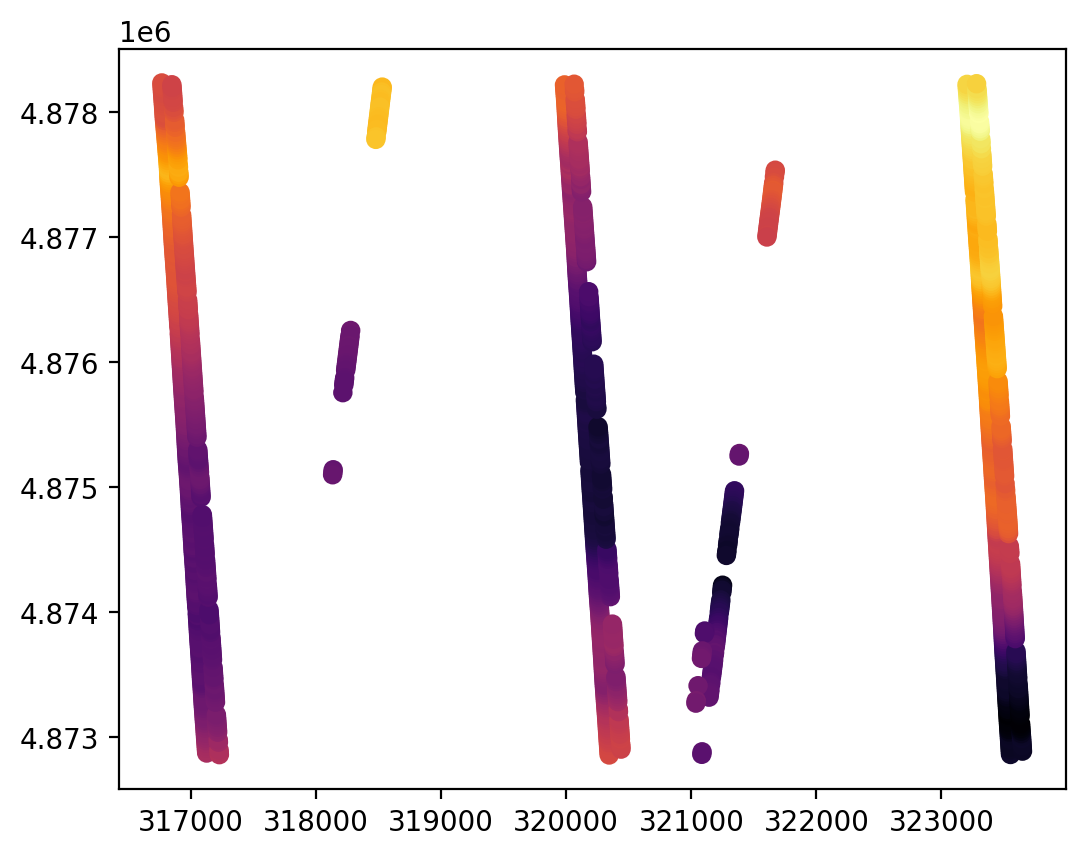

In [37]:
gf_surface.plot(column='h_mean',cmap='inferno')

<Axes: >

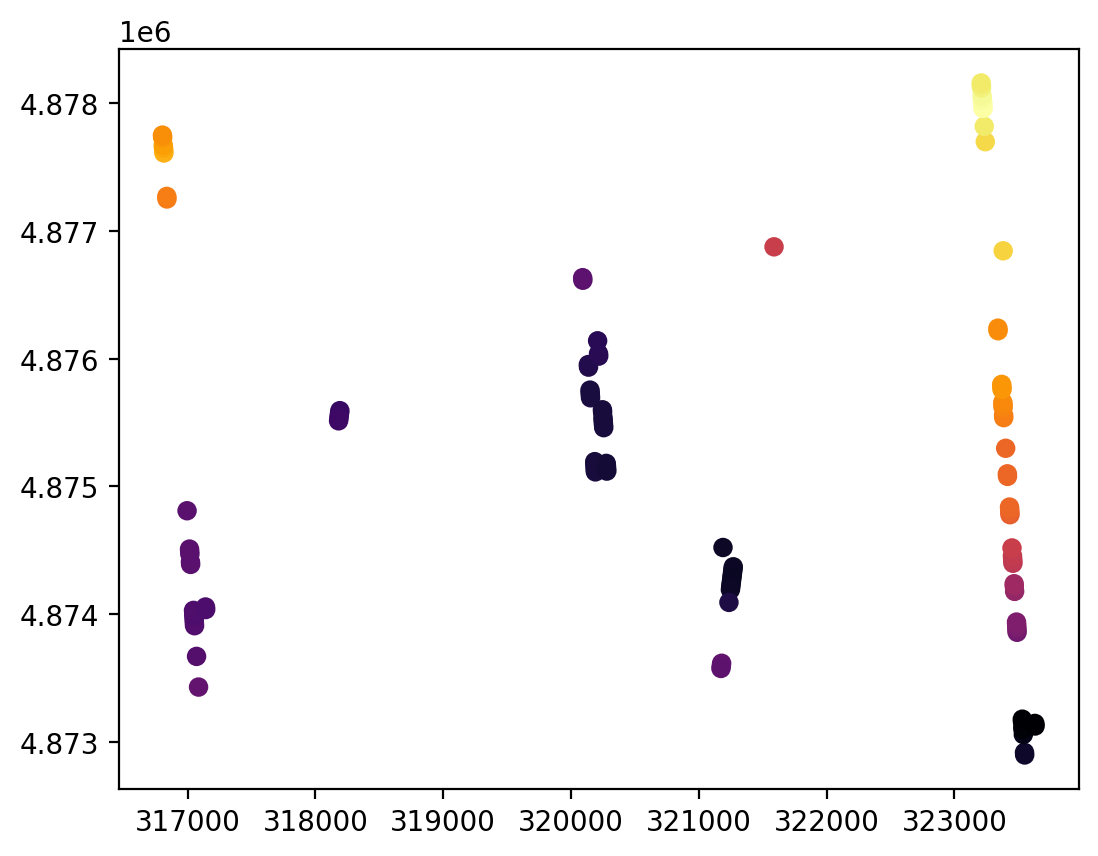

In [38]:
gf_ground.plot(column='h_mean',cmap='inferno')

In [39]:
gf_ground.describe()

,time,h_sigma,n_fit_photons,cycle,w_surface_window_final,pflags,segment_id,y_atc,dh_fit_dx,region,h_mean,spot,rgt,gt,rms_misfit,x_atc,easting,northing
count,124,124.000000,124.000000,124.0,124.000000,124.0,124.000000,124.000000,124.000000,124.000000,124.000000,124.000000,124.000000,124.000000,124.000000,124.0,124.000000,1.240000e+02
mean,2019-08-29 17:16:20.847000,0.136261,27.016129,4.0,4.890611,0.0,331260.096774,6071.078613,0.009341,2.677419,408.575418,3.661290,956.580645,36.612903,0.456565,6639519.0,320924.745322,4.875226e+06
min,2019-08-07 18:14:32.093000,0.015531,10.000000,4.0,3.000000,0.0,244201.000000,-13526.960938,-0.546552,2.000000,181.109205,1.000000,621.000000,10.000000,0.081962,4896738.0,316802.131249,4.872897e+06
25%,2019-09-03 04:43:30.415000,0.051482,12.000000,4.0,3.000000,0.0,244280.750000,7174.358276,-0.028775,2.000000,244.462116,3.000000,1025.000000,30.000000,0.208541,4898336.5,320092.426918,4.874206e+06
50%,2019-09-03 04:43:30.621000,0.114043,15.000000,4.0,3.078046,0.0,244341.500000,7193.750488,0.006817,2.000000,337.735148,4.000000,1025.000000,40.000000,0.379067,4899553.5,321242.078336,4.875126e+06
75%,2019-09-03 04:43:30.973000,0.181047,32.000000,4.0,5.998447,0.0,244458.250000,10396.771973,0.105281,2.000000,586.806314,5.000000,1025.000000,50.000000,0.598141,4901893.5,323383.623293,4.875783e+06
max,2019-09-03 04:43:31.168000,0.621027,192.000000,4.0,16.305677,0.0,757669.000000,13615.701172,0.484797,6.000000,793.973994,6.000000,1025.000000,60.000000,1.818550,15175517.0,323632.373413,4.878157e+06
std,NaN,0.112298,27.516435,0.0,2.802125,0.0,193297.953927,8163.742676,0.179403,1.506346,191.506950,1.545448,152.140986,15.454475,0.332701,3869503.5,2483.122055,1.414022e+03


In [40]:
gf_surface.describe()

,time,h_sigma,n_fit_photons,cycle,w_surface_window_final,pflags,segment_id,y_atc,dh_fit_dx,region,h_mean,spot,rgt,gt,rms_misfit,x_atc,easting,northing
count,1583,1583.000000,1583.000000,1583.0,1583.000000,1583.000000,1583.000000,1583.000000,1583.000000,1583.000000,1583.000000,1583.000000,1583.000000,1583.00000,1583.000000,1583.0,1583.000000,1.583000e+03
mean,2019-08-31 17:48:21.960000,0.591298,36.593809,4.0,19.409079,0.030954,292004.203411,8344.908203,0.035775,2.371447,465.453775,3.464940,987.483891,34.64940,2.932585,5853681.5,320224.069760,4.875539e+06
min,2019-08-07 18:14:31.945000,0.000000,10.000000,4.0,3.000000,0.000000,244199.000000,-13525.928711,-0.972055,2.000000,193.863728,1.000000,621.000000,10.00000,0.000000,4896698.0,316765.254596,4.872853e+06
25%,2019-09-03 04:43:30.548000,0.356838,16.000000,4.0,14.019532,0.000000,244285.000000,7174.510498,-0.112417,2.000000,347.843998,2.000000,1025.000000,20.00000,2.171262,4898421.5,317096.689464,4.874170e+06
50%,2019-09-03 04:43:30.802000,0.498577,36.000000,4.0,18.634924,0.000000,244359.000000,10310.299805,0.047612,2.000000,439.332192,3.000000,1025.000000,30.00000,2.749688,4899904.5,320224.327646,4.875533e+06
75%,2019-09-03 04:43:31.015000,0.734903,54.000000,4.0,24.914022,0.000000,244431.500000,13516.229492,0.178000,2.000000,588.617638,5.000000,1025.000000,50.00000,3.458524,4901357.5,323312.151710,4.876918e+06
max,2019-09-03 04:43:31.458000,3.270990,103.000000,4.0,30.000000,4.000000,757705.000000,13616.171875,0.989934,6.000000,810.240121,6.000000,1025.000000,60.00000,8.906391,15176239.0,323649.336919,4.878229e+06
std,NaN,0.349208,21.219279,0.0,6.717299,0.292644,149007.454958,6789.706543,0.226544,1.161321,154.879325,1.665407,117.293395,16.65407,1.174742,2982881.0,2566.644068,1.561711e+03


In [41]:
## Functions
def load_stv_product_local(href, overview_level=None):
    if overview_level is not None:
        da = xr.open_dataarray(
            href,
            engine="rasterio",
            mask_and_scale=True,
            backend_kwargs={"open_kwargs": {"overview_level": overview_level}},
        ).squeeze()
    else:
        da = xr.open_dataarray(
            href,
            engine="rasterio",
            mask_and_scale=True,
        ).squeeze()
    return da


In [44]:
bart_dsm = load_stv_product_local('BART_first_idw_processing/BART_extent-DSM_mos.tif')

In [45]:
import coincident

/panfs/ccds02/nobackup/people/sbhusha1/sw/coincident/src/coincident/io/download.py:28: TqdmExperimentalWarning: Using `tqdm.autonotebook.tqdm` in notebook mode. Use `tqdm.tqdm` instead to force console mode (e.g. in jupyter console)
  from tqdm.autonotebook import tqdm
/panfs/ccds02/nobackup/people/sbhusha1/sw/coincident/src/coincident/search/main.py:15: UserWarning: Unable to authenticate with Maxar API. Please set MAXAR_API_KEY environment variable.
  from coincident.search import neon_api, opentopo_api, stac, wesm


In [47]:
gf_surface['elev_diff'] = coincident.plot.utils.sample_dem_at_points(bart_dsm,gf_surface,diff_col='h_mean')["elev_diff"]

In [50]:
gf_surface.elev_diff.mean()

np.float64(-0.36507976350317767)

In [51]:
gf_surface.elev_diff.median()

np.float64(-0.8328226905573501)